# Session 8- Clustering

## Clustering- Kmeans algorythm(lloyd) - inertia and silhouette score ( for Finding K) - elbow  - kmeans ++ (a mehtod for initiation start)- Merging models (Bagging and Boosting)- StandardScaler 

In [23]:
#K-Means Algorithm (Lloyd)
#1. Pick K centers (K-Means++ spreads them apart)
#2. Assign each point to nearest center
#3. Move centers to average of their points
#4. Repeat 2-3 until centers stop moving


#Finding Optimal K
#Elbow Method (Inertia):
#Inertia = sum of squared distances to cluster center
#Plot K vs Inertia → "Elbow" = best K


#Silhouette Score:
#Measures how similar a point is to its own cluster vs others
#Range: -1 (wrong) to +1 (perfect)
#Higher = better clustering



#Formule silhouette:

#For EACH point i:
#Silhouette(i) = (b_i - a_i) / max(a_i, b_i)
#a_i	Average distance from point i to all other points in its OWN cluster
#b_i	Average distance from point i to all points in the NEAREST other cluster
#a_i = "How close am I to my own cluster?"
 #     → Small a = tight cluster ✅

#b_i = "How far am I from the next closest cluster?"
 #     → Large b = well separated ✅

#Example:
#Cluster A:  [1, 2, 3]     Cluster B:  [8, 9, 10]

#Point i = 2 (in Cluster A)

#Step 1: Calculate a_i
 # Distance to 1: |2-1| = 1
  #Distance to 3: |2-3| = 1
  #a_i = (1 + 1) / 2 = 1.0  ← Close to own cluster ✅

#Step 2: Calculate b_i
 # Distance to 8: |2-8| = 6
  #Distance to 9: |2-9| = 7
  #Distance to 10: |2-10| = 8
  #b_i = (6 + 7 + 8) / 3 = 7.0  ← Far from other cluster ✅

#Step 3: Silhouette
 # s(i) = (7.0 - 1.0) / max(1.0, 7.0)
  #     = 6.0 / 7.0
   #    = 0.857  ← Good clustering!
#for each point calculate then get the mean of all




# Bagging VS Boosting (merging models)
#┌──────────┬─────────────────────┬──────────────────────┬──────────────────────────┐
#│          │       Bagging       │       Boosting        │        Stacking          │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ How?     │ Models trained      │ Models trained       │ Different model TYPES    │
#│          │ in PARALLEL         │ in SEQUENCE          │ combined, meta-model     │
#│          │                     │                      │ learns who to trust      │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ Focus    │ Reduce VARIANCE     │ Reduce BIAS          │ Best of all worlds       │
#│          │ (fixes overfitting) │ (fixes underfitting) │                          │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ Models   │ Independent         │ Each learns from     │ Independent +            │
#│          │ of each other       │ previous mistakes    │ meta-learner on top      │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ Weight   │ Equal vote for      │ More weight to       │ Meta-model decides       │
#│          │ all models          │ better models        │ weights automatically     │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ Example  │ Random Forest       │ AdaBoost, XGBoost,   │ StackingClassifier       │
#│          │                     │ Gradient Boosting    │                          │
#├──────────┼─────────────────────┼──────────────────────┼──────────────────────────┤
#│ Risk     │ Can't fix bias      │ Can overfit if       │ Complex, needs careful   │
#│          │ (systematic errors) │ too many iterations  │ tuning                   │
#└──────────┴─────────────────────┴──────────────────────┴──────────────────────────┘

#BAGGING (Parallel):
 # Model 1 ─┐
 # Model 2 ─┼→ Majority Vote → Final Prediction
 # Model 3 ─┘
  #(All train independently on different data samples)

#BOOSTING (Sequential):
 # Model 1 → Mistakes → Model 2 focuses on mistakes → Model 3 focuses on remaining mistakes → Final Prediction
  #(Each model learns from previous errors)

## Clustering (Kmeans (lloyd)) 

In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons 
from sklearn.datasets import make_circles 
from sklearn.datasets import make_blobs

In [25]:
X, y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    cluster_std = 1.5,
    random_state = 42
)

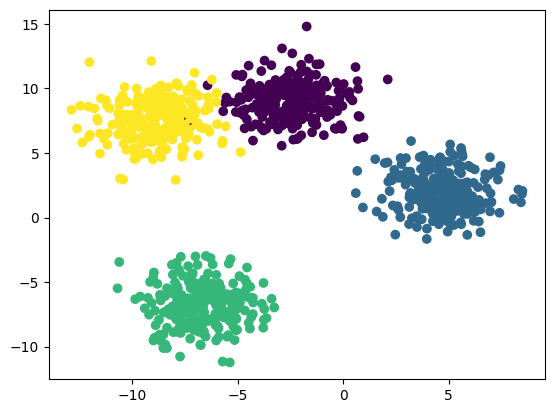

In [28]:
plt.scatter(X[:,0],X[:,1],c = y)

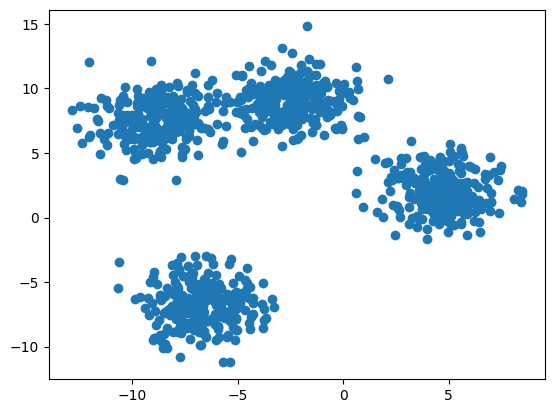

In [27]:
plt.scatter(X[:,0],X[:,1])

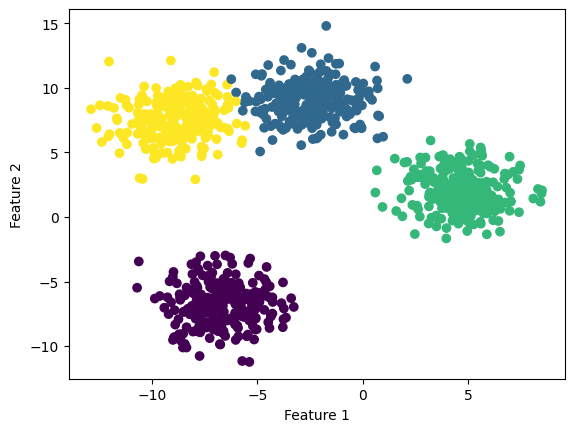

In [7]:
# Kmeans- and its prediction
model = KMeans (n_clusters=4)
model.fit(X)
predict = model.predict(X)
plt.xlabel('Feature 1')
plt.ylabel("Feature 2")

plt.scatter(X[:,0],X[:,1],c=predict)



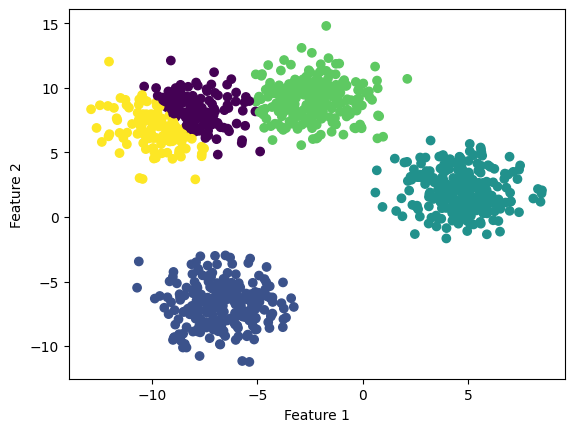

In [8]:
# K = 5
model = KMeans (n_clusters=5)
model.fit(X)
predict = model.predict(X)
plt.xlabel('Feature 1')
plt.ylabel("Feature 2")

plt.scatter(X[:,0],X[:,1],c=predict)


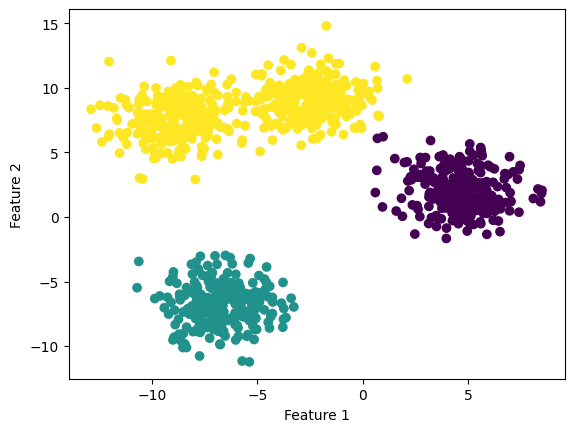

In [9]:
# K =3
model = KMeans (n_clusters=3)
model.fit(X)
predict = model.predict(X)
plt.xlabel('Feature 1')
plt.ylabel("Feature 2")

plt.scatter(X[:,0],X[:,1],c=predict)


#see that if K is bigger than the real K it is not problematic but if is less is

1 69257.33081597075
2 35609.14523404312
3 9736.011640355166
4 4359.724247898586
5 3964.101588206393
6 3564.9068534701455
7 3224.763758759177
8 3013.0370298849034


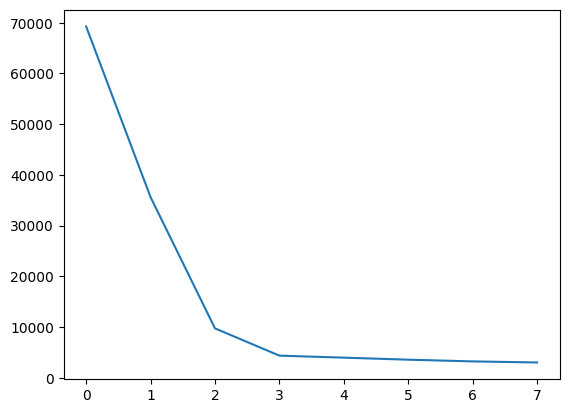

In [10]:
# Evaluate the K value - find best value for K
#inertia
inertia = []

for i in range(1,9):
    model = KMeans(n_clusters = i)
    model.fit_predict(X)

    #list error
    inertia.append(model.inertia_)
    print(i,model.inertia_)
inertia


plt.plot(inertia)

#3 is elbow so it is the best K - Elbow role

K=2: Silhouette = 0.5558
K=3: Silhouette = 0.6936
K=4: Silhouette = 0.6877
K=5: Silhouette = 0.5666
K=6: Silhouette = 0.4735
K=7: Silhouette = 0.4072
K=8: Silhouette = 0.4206


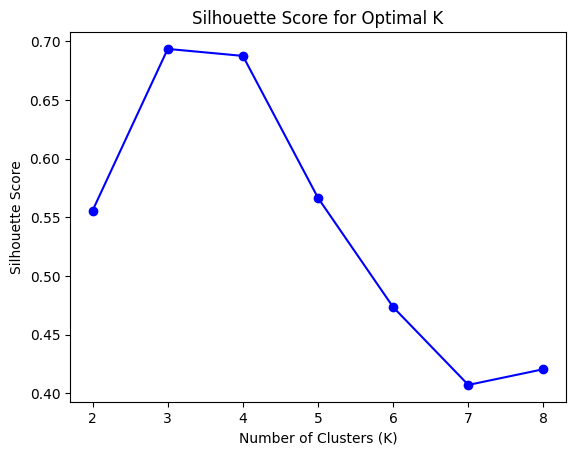

In [11]:
# Silhouette_score
sil=[]
for k in range(2, 9):  # Start from 2 (silhouette needs at least 2 clusters)
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)  # ✅ Save labels!
    
    score = silhouette_score(X, labels)
    sil.append(score)
    print(f"K={k}: Silhouette = {score:.4f}")

# Plot
plt.plot(range(2, 9), sil, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.show()

 Make_moons and make_circles to show why Kmeans is not a good appriach in some cases (such as dense data)

 K-Means is GOOD for:
  → Round, equal-sized (each cluster same number ofdata), well-separated, low-dim clusters

K-Means FAILS for:
  → Irregular shapes, different sizes, overlapping, high-dim dense data

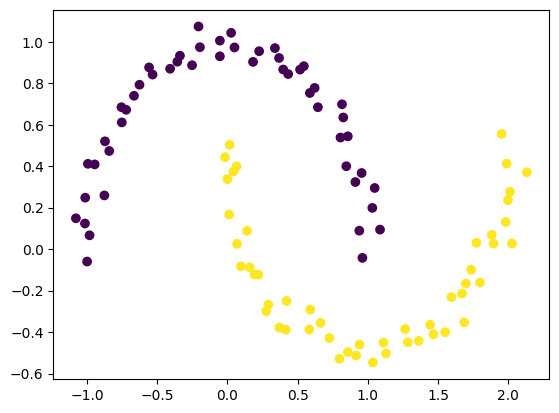

In [12]:
X,y = make_moons(
n_samples = 100,
    noise = .05,
    random_state = 42
)
plt.scatter(X[:,0],X[:,1],c = y)

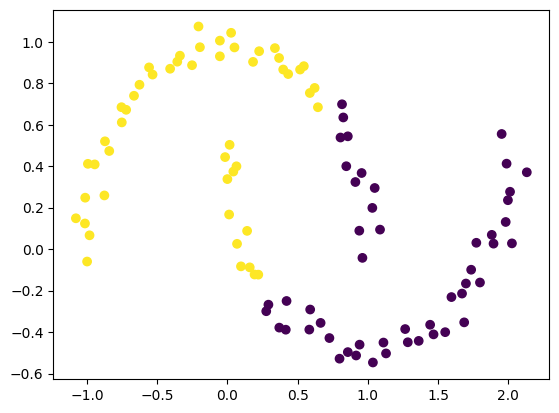

In [13]:
model = KMeans(n_clusters = 2)
predict= model.fit_predict(X)

plt.scatter(X[:,0],X[:,1],c = predict)

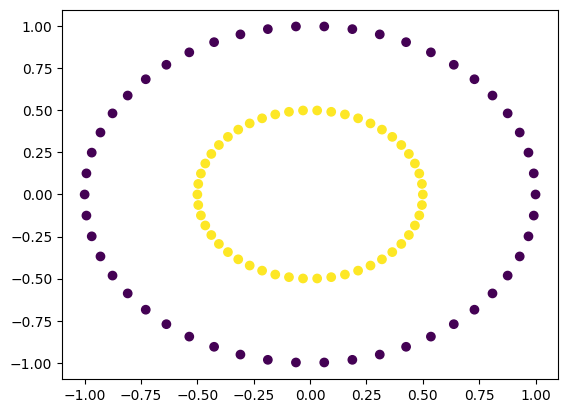

In [14]:
#circles
X,y = make_circles(n_samples=100, factor=0.5, random_state=42)
plt.scatter(X[:,0],X[:,1],c = y)


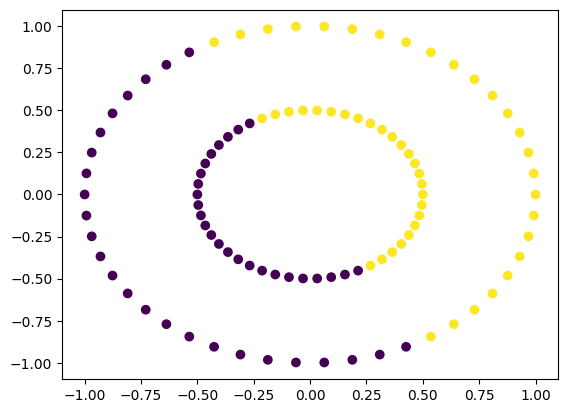

In [15]:
model = KMeans(n_clusters = 2)
predict= model.fit_predict(X)

plt.scatter(X[:,0],X[:,1],c = predict)

## Real data (BTC - Oil- Gold- Ethereum) - compare them (using standardscaler)

In [16]:
btc = pd.read_csv('bitcoin.csv')
eth = pd.read_csv('etherium.csv')

oil = pd.read_csv("oil.csv")
gold = pd.read_csv('gold.csv')

print('BTC:' ,btc.info())

print('ETH:' ,eth.info())

print('Oil:' ,oil.info())

print('Gold:' ,gold.info())


# ERROR : the oil file is eth file and gold file is btc file but different name  - mistake in download so ignore them till you get true data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2921 non-null   object 
 1   Close   2921 non-null   float64
 2   High    2921 non-null   float64
 3   Low     2921 non-null   float64
 4   Open    2921 non-null   float64
 5   Volume  2921 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 137.1+ KB
BTC: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2921 non-null   object 
 1   Close   2921 non-null   float64
 2   High    2921 non-null   float64
 3   Low     2921 non-null   float64
 4   Open    2921 non-null   float64
 5   Volume  2921 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 137.1+ KB
ETH: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex

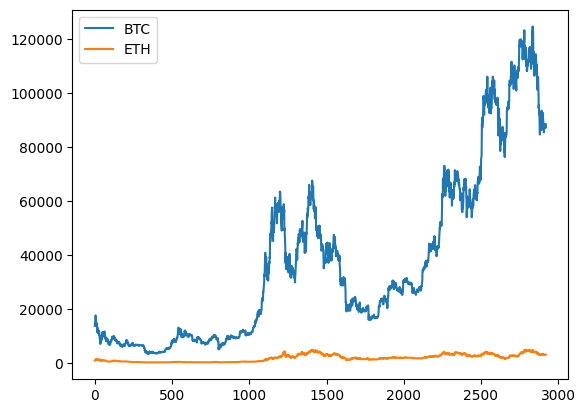

In [17]:
# without scaling:
plt.plot(btc.Close,label = 'BTC')
plt.plot(eth.Close,label = 'ETH')
plt.legend()

StandardScaler = mean ---> 0 std--->1 : HOW:

Mean to 0 --> X-X.mean() (for each X then sum of them)

Std to 1 --> X-X.mean / std

In [18]:
btc.Close

0       13657.200195
1       14982.099609
2       15201.000000
3       15599.200195
4       17429.500000
            ...     
2916    87301.429688
2917    87802.156250
2918    87835.835938
2919    87138.140625
2920    88430.132812
Name: Close, Length: 2921, dtype: float64

In [19]:
#befor scaling:
print(btc.Close.mean(), btc.Close.std())

#after scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
btc_scaled = scaler.fit_transform(btc.Close.values.reshape(-1,1))

print(btc_scaled.mean(),btc_scaled.std())

37256.68133822829 32206.38560193725
7.784103917947006e-17 1.0


In [20]:
#ETH Scaling
scaler = StandardScaler()
eth_scaled = scaler.fit_transform(eth.Close.values.reshape(-1,1))

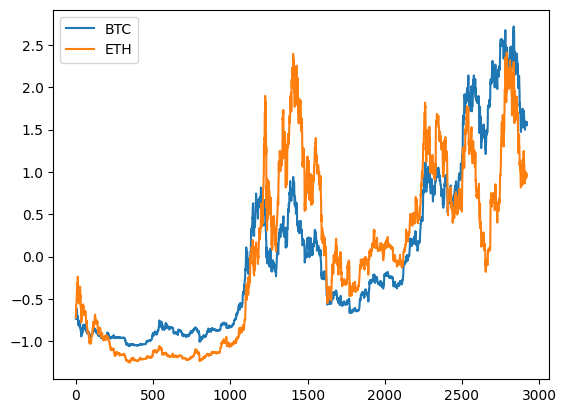

In [21]:
# show now
plt.plot(btc_scaled,label="BTC")
plt.plot(eth_scaled,label='ETH')
plt.legend()

In [70]:
# oil
oil = pd.read_csv('oil_wti.csv')
# Convert Date column to datetime
oil['Date'] = pd.to_datetime(oil['Date'])

# Filter between two dates
start = '2018-01-02'
end = '2025-12-30'

oil_same = oil[(oil['Date'] >= start) & (oil['Date'] <= end)]

oil_same.drop(columns=["Adj Close"], inplace=True)
oil_same

C:\Users\top\AppData\Local\Temp\ipykernel_16636\2962140893.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oil_same.drop(columns=["Adj Close"], inplace=True)


,Date,Close,High,Low,Open,Volume
0,2018-01-02,60.369999,60.740002,60.099998,60.200001,510313
1,2018-01-03,61.630001,61.970001,60.279999,60.389999,673859
2,2018-01-04,62.009998,62.209999,61.590000,61.959999,654363
3,2018-01-05,61.439999,62.040001,61.090000,61.900002,563036
4,2018-01-08,61.730000,61.970001,61.340000,61.610001,616474
...,...,...,...,...,...,...
2007,2025-12-23,58.380001,58.560001,57.740002,57.950001,183633
2008,2025-12-24,58.349998,58.750000,58.130001,58.470001,111762
2009,2025-12-26,56.740002,58.880001,56.650002,58.349998,166669
2010,2025-12-29,58.080002,58.299999,56.910000,57.040001,178590


In [74]:
# make same data 
btc['Date'] = pd.to_datetime(btc['Date'])
btc_same =btc[(btc['Date'] >= start) & (btc["Date"] <= end)]
btc_same

eth['Date'] = pd.to_datetime(eth['Date'])
eth_same = eth[(eth['Date'] >= start) & (eth['Date'] <= end)]


print(btc_same.shape, eth_same.shape, oil_same.shape)



(2012, 6) (2920, 6) (2012, 6)


In [81]:
# Scaling
scaler = StandardScaler()

btc_same_scaled = scaler.fit_transform(btc_same.Close.values.reshape(-1,1))

eth_same_scaled = scaler.fit_transform (eth_same.Close.values.reshape(-1,1))

oil_same_scaled = scaler.fit_transform (oil_same.Close.values.reshape(-1,1))

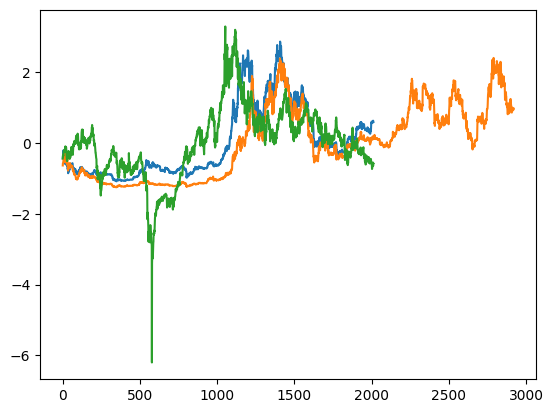

In [82]:
plt.plot(btc_same_scaled,label = 'BTC')
plt.plot(eth_same_scaled, label = "ETH")
plt.plot(oil_same_scaled, label = "OIL")

In [120]:
#set:
numbers = [1, 2, 2, 3, 3, 3, 4]
unique = set(numbers)
print(unique)  # {1, 2, 3, 4}  ← No duplicates!

#  &
ali_bought = {'Milk', 'Bread', 'Eggs'}
sara_bought = {'Milk', 'Bread', 'Butter'}

common = ali_bought & sara_bought
print(common)  # {'Milk', 'Bread'}  ← Both bought these


#isin
import pandas as pd

df = pd.DataFrame({
    'Name': ['Ali', 'Sara', 'Reza', 'Mina'],
    'Age': [22, 25, 30, 28]
})

# Keep only Ali and Mina
names_to_keep = {'Ali','Mina'}

filtered = df[df['Name'].isin(names_to_keep)]
print(filtered)

{1, 2, 3, 4}
{'Bread', 'Milk'}
   Name  Age
0   Ali   22
3  Mina   28


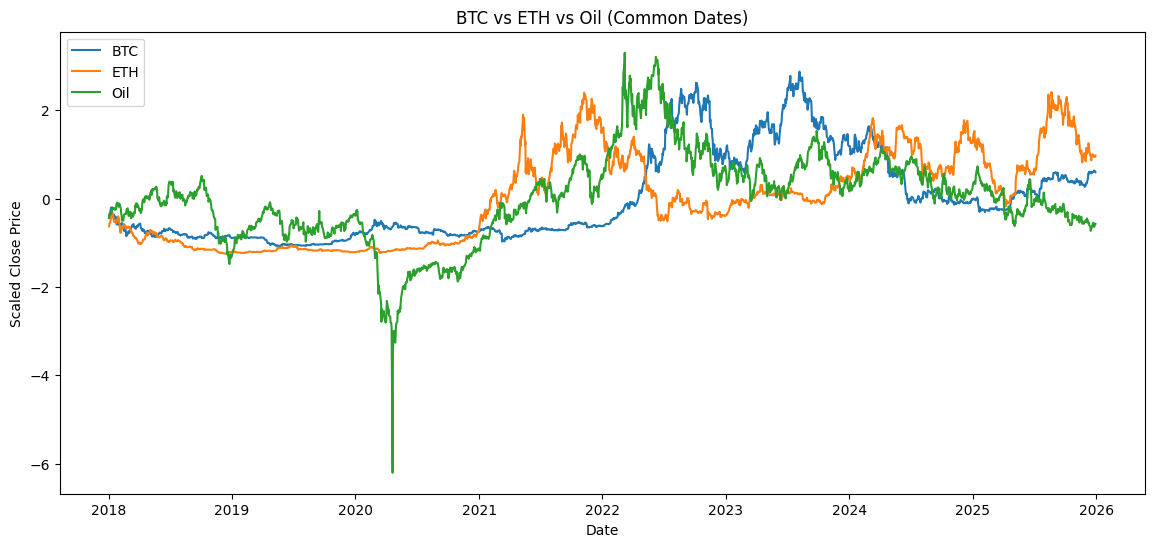

In [121]:
# Find common dates show a better 
common_dates = set(btc['Date']) & set(eth['Date']) & set(oil['Date']) # finds common date 
#A set is an unordered collection of unique values. No duplicates.

btc_common = btc[btc['Date'].isin(common_dates)].sort_values('Date')
eth_common = eth[eth['Date'].isin(common_dates)].sort_values('Date')
oil_common = oil[oil['Date'].isin(common_dates)].sort_values('Date')

# Scale
btc_common_scaled = scaler.fit_transform(btc_common[['Close']])
eth_common_scaled = scaler.fit_transform(eth_common[['Close']])
oil_common_scaled = scaler.fit_transform(oil_common[['Close']])

# Plot with real dates
plt.figure(figsize=(14, 6))
plt.plot(btc_common['Date'], btc_common_scaled, label='BTC')
plt.plot(eth_common['Date'], eth_common_scaled, label='ETH')
plt.plot(oil_common['Date'], oil_common_scaled, label='Oil')
plt.xlabel('Date')
plt.ylabel('Scaled Close Price')
plt.title('BTC vs ETH vs Oil (Common Dates)')
plt.legend()
plt.show()

In [122]:
btc_same.isna().sum()
eth_same.isna().sum()
eth_only = set(eth_same['Date']) - set(btc_same['Date'])
eth_only

btc_only = set(btc_same['Date']) - set(eth_same['Date'])
btc_only

set()